# 📊 Evidência Espectral e de Coeficientes: P₀ > P₁ > P₂

**Argumento central da tese:**
> *Amostras mais antigas (m=1, m=2) contribuem menos para a não-linearidade do PA. Portanto, a complexidade do modelo MP deve ser concentrada no instante atual (m=0), com redução progressiva para atrasos maiores: P₀ ≥ P₁ ≥ P₂.*

Este notebook produz **três evidências complementares** que juntas sustentam esse argumento:

| # | Análise | Argumento |
|---|---|---|
| 1 | **Magnitude dos coeficientes** por atraso | Os coeficientes `|h_{p,m}|` decaem com m → o PA tem memória curta |
| 2 | **Sensibilidade do NMSE** a cada Pₘ | Aumentar P₀ reduz mais o NMSE do que aumentar P₁ ou P₂ |
| 3 | **Espectro do sinal de erro** residual | P₀ alto → maior supressão espectral do erro (in-band e adjacent) |

## 0 · Configuração

In [8]:
# ─── EDITE AQUI ────────────────────────────────────────────────────────────
MAT_FILE = "in_out_SBRT2_direto.mat"   # arquivo .mat com os dados do PA
MAT_FILE = "data_LDMOS_formatted_4500p.mat"   # arquivo .mat com os dados do PA

FS_MHZ   = 61.44                        # taxa de amostragem [MHz]
M        = 2                            # profundidade de memória (atrasos 0,1,2)
P_MAX    = 5                            # ordem máxima avaliada
# ────────────────────────────────────────────────────────────────────────────

## 1 · Importações e utilidades

In [9]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import welch
from itertools import product as iproduct
import os
plt.rcParams.update({"figure.dpi": 130, "axes.grid": True,
                     "grid.alpha": 0.4, "font.size": 11})

INPUT_DIT = 'INPUT'
OUTPUT_DIR = 'OUTPUT'

mat = 'data_LDMOS_formatted_4500p.mat'
# ── Carrega dados ─────────────────────────────────────────────────────────
mat   = sio.loadmat(os.path.join('..', INPUT_DIT, MAT_FILE))
x_ext = mat["in_extraction"].flatten()
y_ext = mat["out_extraction"].flatten()
x_val = mat["in_validation"].flatten()
y_val = mat["out_validation"].flatten()
print(f"Extração : {len(x_ext):,} amostras")
print(f"Validação: {len(x_val):,} amostras")

# ── Funções do modelo MP ──────────────────────────────────────────────────
def build_phi(x, M, ordens):
    """Matriz de regressão para MP com ordens variáveis por atraso."""
    N = len(x)
    cols = []
    for m, Pm in enumerate(ordens):
        xm = x[M - m : N - m if m > 0 else None]
        for p in range(1, Pm + 1):
            cols.append(xm * np.abs(xm) ** (p - 1))
    return np.column_stack(cols)

def fit_model(x_tr, y_tr, x_vl, y_vl, M, ordens):
    """Estima coeficientes e retorna (coef, y_model, erro, NMSE_dB)."""
    Phi_tr = build_phi(x_tr, M, ordens)
    coef   = np.linalg.lstsq(Phi_tr, y_tr[M:], rcond=None)[0]
    Phi_vl = build_phi(x_vl, M, ordens)
    y_mod  = Phi_vl @ coef
    y_real = y_vl[M:]
    e      = y_real - y_mod
    nmse   = 10 * np.log10(np.sum(np.abs(e)**2) / np.sum(np.abs(y_real)**2))
    return coef, y_mod, e, nmse

def psd_db(sig, fs, nperseg=4096):
    """PSD via Welch, centralizada em 0, retorna (freq_MHz, dB)."""
    nperseg  = min(nperseg, len(sig))
    noverlap = nperseg // 2
    f, P = welch(sig, fs=fs, window="hann",
                 nperseg=nperseg, noverlap=noverlap, return_onesided=False)
    return np.fft.fftshift(f), 10 * np.log10(np.fft.fftshift(P) + 1e-20)

print("Funções carregadas.")

Extração : 4,500 amostras
Validação: 4,500 amostras
Funções carregadas.


---
## EVIDÊNCIA 1 · Magnitude dos Coeficientes por Atraso

**Lógica:** No modelo MP, cada coeficiente `h_{p,m}` pondera a contribuição não-linear de ordem `p` do sinal atrasado `m` amostras. Se `|h_{p,m}|` **cai com m**, significa que o PA é mais sensível ao sinal atual do que a versões passadas — ou seja, a memória é fraca e de curto alcance.

**Esperado:** `|h_{p,0}| >> |h_{p,1}| > |h_{p,2}|` para toda ordem `p`.

MP completo (P=5, M=2) → NMSE = -38.47 dB


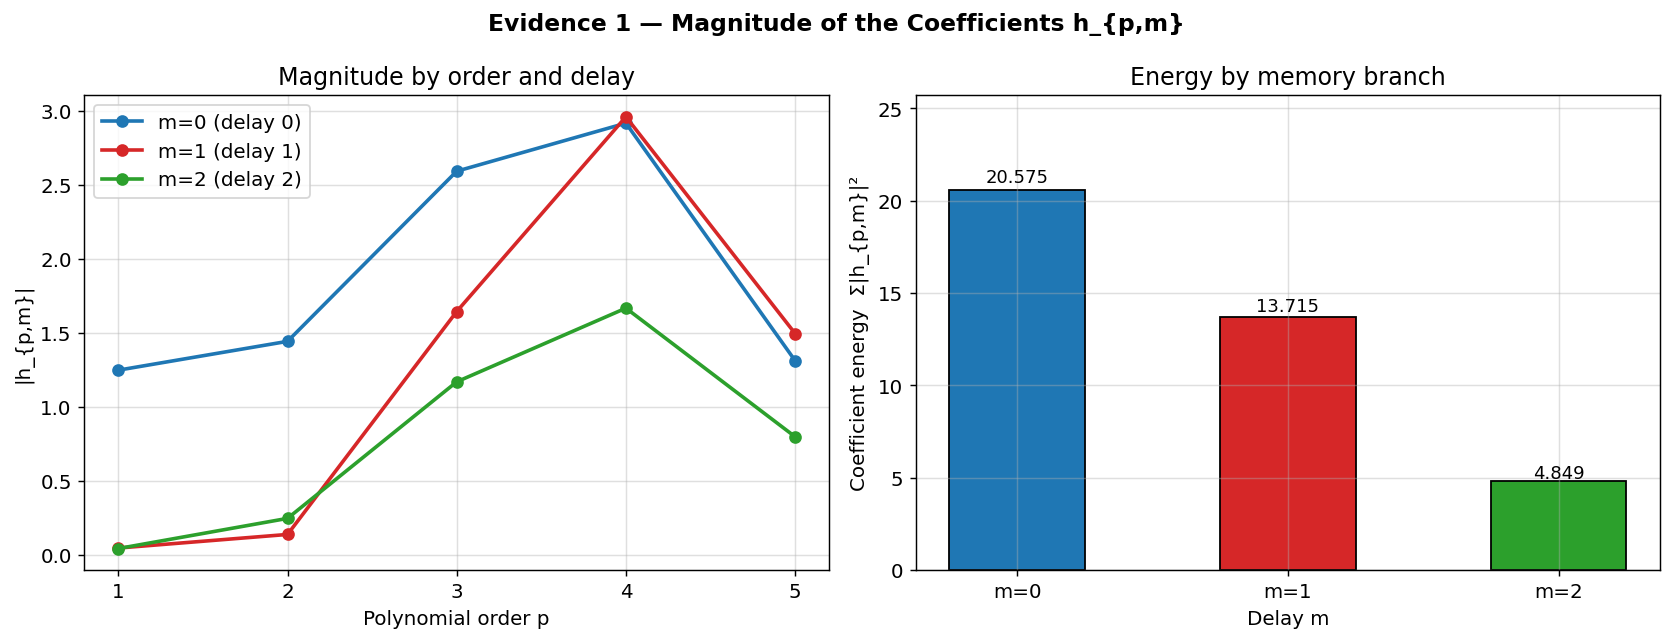


Interpretação:
  Se a energia cai com m → o PA responde principalmente ao instante atual.
  → Justifica P₀ > P₁ > P₂ na alocação de complexidade.


In [10]:
# Treina MP com P uniforme (P_MAX em todos os atrasos) para expor os coeficientes
ordens_full = tuple([P_MAX] * (M + 1))
coef_full, _, _, nmse_full = fit_model(x_ext, y_ext, x_val, y_val, M, ordens_full)
print(f"MP completo (P={P_MAX}, M={M}) → NMSE = {nmse_full:.2f} dB")

# Reorganiza coeficientes em matriz [atraso m × ordem p]
coef_mat = coef_full.reshape(M + 1, P_MAX)   # shape: (3, P_MAX)

# ── Figura: magnitude dos coeficientes ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Evidence 1 — Magnitude of the Coefficients h_{p,m}",
             fontsize=13, fontweight="bold")

cores  = ["#1f77b4", "#d62728", "#2ca02c"]
ordens = np.arange(1, P_MAX + 1)

# Painel A: magnitude vs ordem, uma curva por atraso
ax = axes[0]
for m in range(M + 1):
    ax.plot(ordens, np.abs(coef_mat[m]),
            marker="o", lw=2, color=cores[m], label=f"m={m} (delay {m})")
ax.set_xlabel("Polynomial order p")
ax.set_ylabel("|h_{p,m}|")
ax.set_title("Magnitude by order and delay")
ax.legend()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

# Painel B: magnitude total por atraso (soma dos |h_{p,m}|)
ax2 = axes[1]
energia_por_atraso = np.sum(np.abs(coef_mat)**2, axis=1)  # energia L2 por ramo
bars = ax2.bar([f"m={m}" for m in range(M + 1)],
               energia_por_atraso, color=cores[:M+1], edgecolor="black", width=0.5)
for bar, val in zip(bars, energia_por_atraso):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f"{val:.3f}", ha="center", fontsize=10)
ax2.set_xlabel("Delay m")
ax2.set_ylabel("Coefficient energy  Σ|h_{p,m}|²")
ax2.set_title("Energy by memory branch")
ax2.set_ylim(0, energia_por_atraso.max() * 1.25)

plt.tight_layout()
# plt.savefig("ev1_magnitude_coeficientes.png", bbox_inches="tight")
plt.show()

print("\nInterpretação:")
print("  Se a energia cai com m → o PA responde principalmente ao instante atual.")
print("  → Justifica P₀ > P₁ > P₂ na alocação de complexidade.")

---
## EVIDÊNCIA 2 · Sensibilidade do NMSE a P₀, P₁ e P₂

**Lógica:** Mantém-se dois parâmetros fixos em 1 e varia-se o terceiro de 1 a P_MAX. A **inclinação** da curva NMSE×Pₘ indica o quanto aquele atraso ainda tem informação não-linear a capturar.

**Esperado:** A curva de P₀ cai muito mais acentuadamente do que P₁ e P₂.

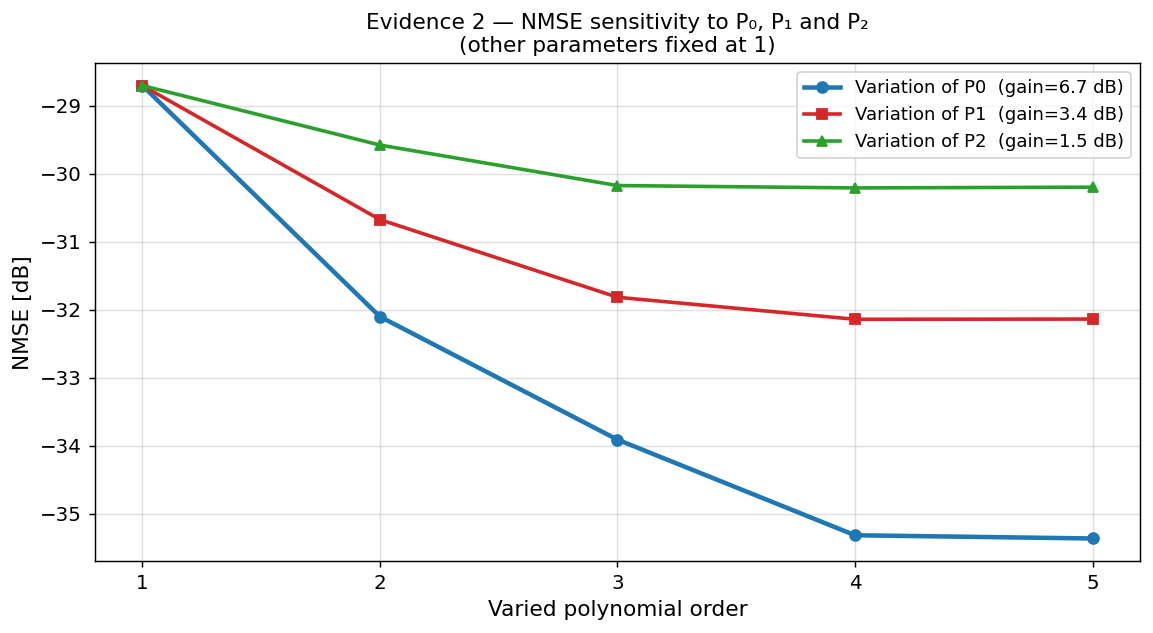


Ganho de NMSE ao aumentar cada parâmetro de 1 a 5 :
  P0: -28.71 → -35.36 dB  (Δ = 6.66 dB)
  P1: -28.71 → -32.14 dB  (Δ = 3.43 dB)
  P2: -28.71 → -30.20 dB  (Δ = 1.49 dB)

Interpretação:
  Maior Δ em P₀ → não-linearidade dominante está no instante atual.
  Δ pequeno em P₂ → termos de atraso 2 têm pouca não-linearidade.


In [11]:
resultados_sens = {"P0": [], "P1": [], "P2": []}

for p_var in range(1, P_MAX + 1):
    # Varia P0, fixa P1=P2=1
    _, _, _, nmse = fit_model(x_ext, y_ext, x_val, y_val, M, (p_var, 1, 1))
    resultados_sens["P0"].append(nmse)

    # Varia P1, fixa P0=P2=1
    _, _, _, nmse = fit_model(x_ext, y_ext, x_val, y_val, M, (1, p_var, 1))
    resultados_sens["P1"].append(nmse)

    # Varia P2, fixa P0=P1=1
    _, _, _, nmse = fit_model(x_ext, y_ext, x_val, y_val, M, (1, 1, p_var))
    resultados_sens["P2"].append(nmse)

p_eixo = list(range(1, P_MAX + 1))

fig, ax = plt.subplots(figsize=(9, 5))
estilos = {"P0": ("#1f77b4", "o", 2.5), "P1": ("#d62728", "s", 2.0), "P2": ("#2ca02c", "^", 2.0)}

for param, (cor, mk, lw) in estilos.items():
    vals = resultados_sens[param]
    ganho = vals[0] - vals[-1]   # ganho total ao ir de p=1 a p=P_MAX
    ax.plot(p_eixo, vals, marker=mk, lw=lw, color=cor,
            label=f"Variation of {param}  (gain={ganho:.1f} dB)")

ax.set_xlabel("Varied polynomial order", fontsize=12)
ax.set_ylabel("NMSE [dB]", fontsize=12)
ax.set_title("Evidence 2 — NMSE sensitivity to P₀, P₁ and P₂\n"
             "(other parameters fixed at 1)", fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
# plt.savefig("ev2_sensibilidade_nmse.png", bbox_inches="tight")
plt.show()

print("\nGanho de NMSE ao aumentar cada parâmetro de 1 a", P_MAX, ":")
for k, v in resultados_sens.items():
    print(f"  {k}: {v[0]:.2f} → {v[-1]:.2f} dB  (Δ = {v[0]-v[-1]:.2f} dB)")
print("\nInterpretação:")
print("  Maior Δ em P₀ → não-linearidade dominante está no instante atual.")
print("  Δ pequeno em P₂ → termos de atraso 2 têm pouca não-linearidade.")

---
## EVIDÊNCIA 3 · Espectro do Sinal de Erro Residual

**Lógica:** O espectro do erro `e(n) = y_real(n) − y_model(n)` mostra o quanto de distorção o modelo **não conseguiu capturar**. Se aumentar P₀ produz o maior afundamento espectral do erro (tanto na banda quanto nas adjacências), isso confirma que a não-linearidade principal está em m=0.

**Esperado:** Painel de P₀ → maior redução no espectro de erro. Painéis de P₁, P₂ → pouca mudança.

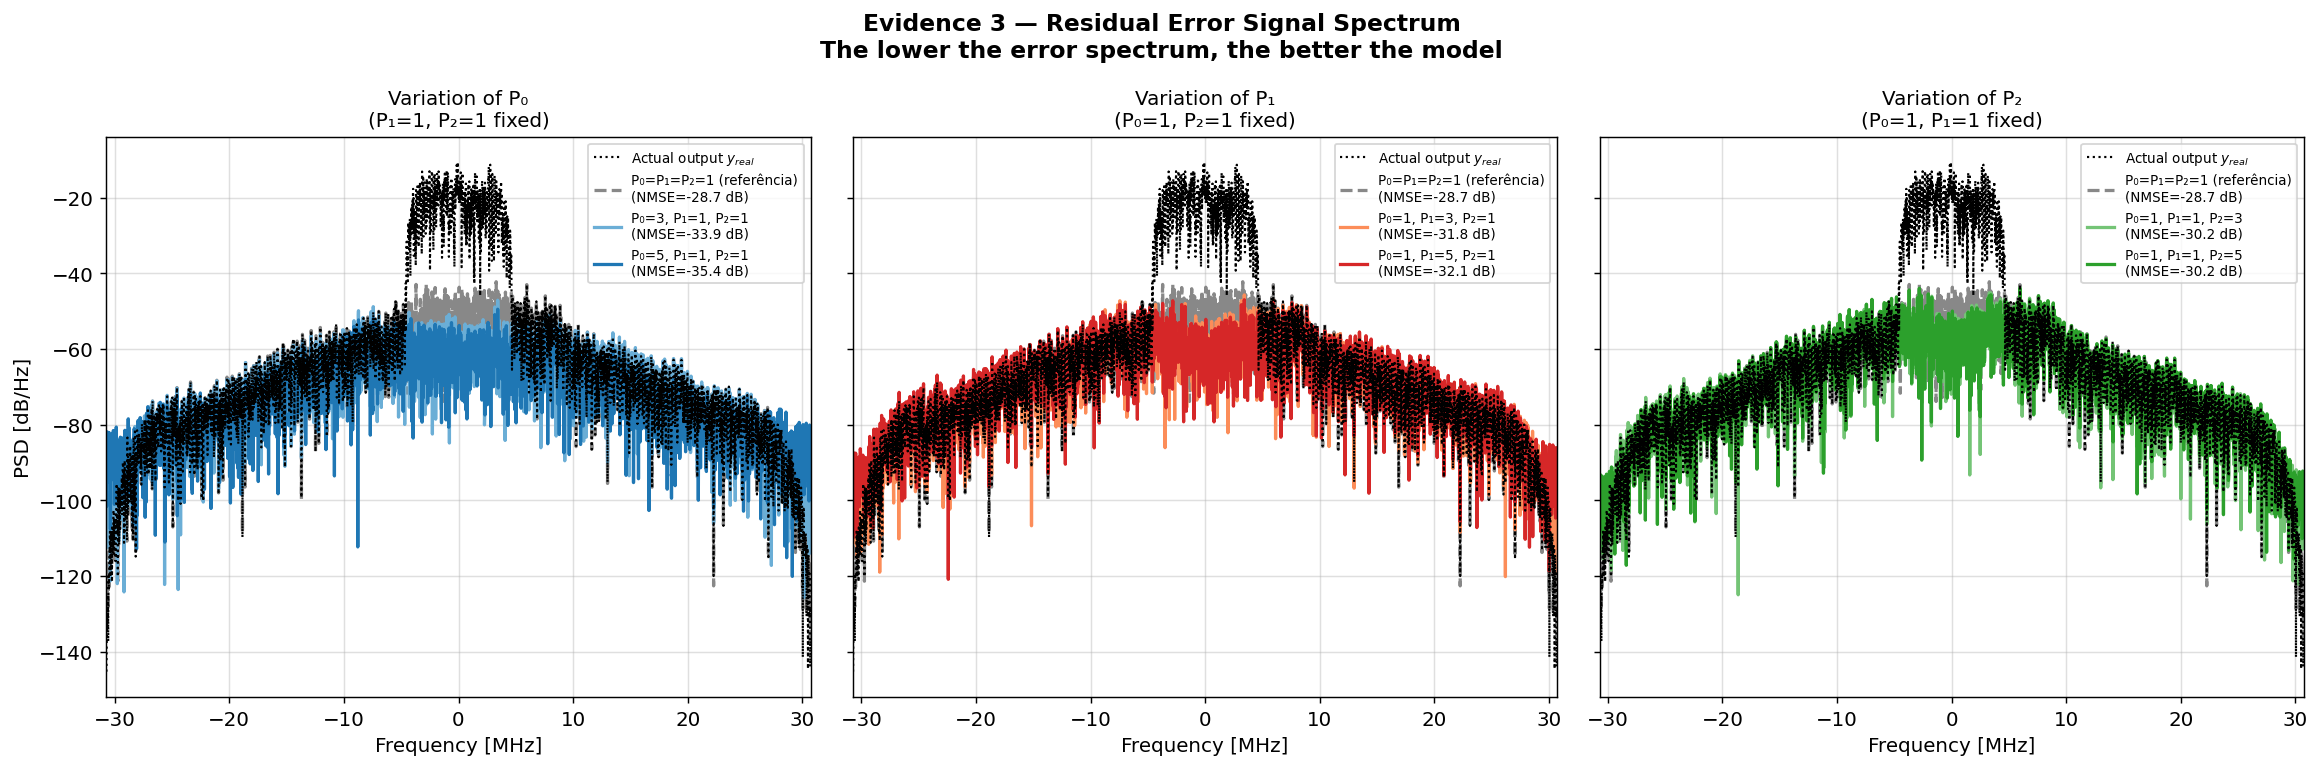

In [12]:
# Modelos selecionados para comparação espectral
configs = [
    # (P0, P1, P2, label, cor, linestyle)
    (1, 1, 1, "P₀=P₁=P₂=1 (referência)", "#888888", "--"),
    # ── Variação de P0 ──
    (3, 1, 1, "P₀=3, P₁=1, P₂=1",        "#6baed6", "-"),
    (5, 1, 1, "P₀=5, P₁=1, P₂=1",        "#1f77b4", "-"),
    # ── Variação de P1 ──
    (1, 3, 1, "P₀=1, P₁=3, P₂=1",        "#fc8d59", "-"),
    (1, 5, 1, "P₀=1, P₁=5, P₂=1",        "#d62728", "-"),
    # ── Variação de P2 ──
    (1, 1, 3, "P₀=1, P₁=1, P₂=3",        "#74c476", "-"),
    (1, 1, 5, "P₀=1, P₁=1, P₂=5",        "#2ca02c", "-"),
]

# Calcula erros para todos
erros = {}
for (P0, P1, P2, label, cor, ls) in configs:
    _, _, e, nmse = fit_model(x_ext, y_ext, x_val, y_val, M, (P0, P1, P2))
    erros[label] = {"erro": e, "nmse": nmse, "cor": cor, "ls": ls,
                    "P0": P0, "P1": P1, "P2": P2}

# PSD da saída real (referência de nível)
y_real_ref = y_val[M:]
f_ref, psd_ref = psd_db(y_real_ref, FS_MHZ)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle("Evidence 3 — Residual Error Signal Spectrum\n"
             "The lower the error spectrum, the better the model",
             fontsize=13, fontweight="bold")

grupos = [
    {"titulo": "Variation of P₀\n(P₁=1, P₂=1 fixed)",
     "filtro": lambda r: r["P1"] == 1 and r["P2"] == 1},
    {"titulo": "Variation of P₁\n(P₀=1, P₂=1 fixed)",
     "filtro": lambda r: r["P0"] == 1 and r["P2"] == 1},
    {"titulo": "Variation of P₂\n(P₀=1, P₁=1 fixed)",
     "filtro": lambda r: r["P0"] == 1 and r["P1"] == 1},
]

for ax, info in zip(axes, grupos):
    # Saída real como referência de nível
    ax.plot(f_ref, psd_ref, color="black", lw=1.2, ls=":",
            label="Actual output $y_{real}$", zorder=5)

    for label, r in erros.items():
        if not info["filtro"](r):
            continue
        f_e, p_e = psd_db(r["erro"], FS_MHZ)
        ax.plot(f_e, p_e, color=r["cor"], lw=1.8, ls=r["ls"],
                label=f"{label}\n(NMSE={r['nmse']:.1f} dB)")

    ax.set_title(info["titulo"], fontsize=11)
    ax.set_xlabel("Frequency [MHz]")
    ax.set_xlim(-FS_MHZ / 2, FS_MHZ / 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.legend(fontsize=7.5, loc="upper right")

axes[0].set_ylabel("PSD [dB/Hz]")
plt.tight_layout()
# plt.savefig("ev3_espectro_erro.png", bbox_inches="tight")
plt.show()

---
## Resumo: As 3 Evidências em Conjunto

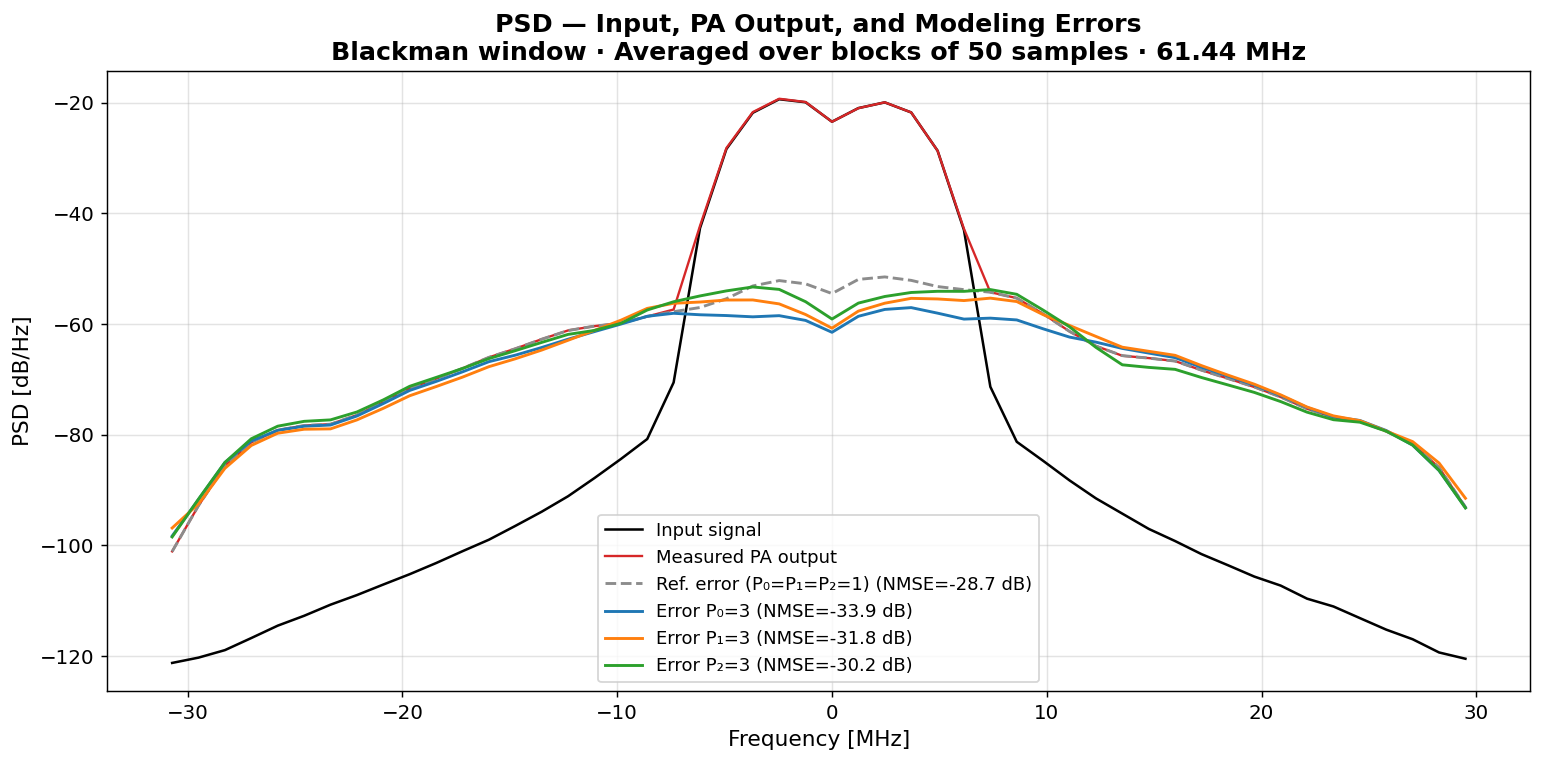

In [13]:
# ── Extra figure: PSD of input, PA output, and modeling errors ───────────
BLOCK_SIZE = 50
PSD_WINDOW = "blackman"

def psd_db_blackman(sig, fs, nperseg=50):
    nperseg = min(nperseg, len(sig))
    f, Pxx = welch(
        sig,
        fs=fs,
        window=PSD_WINDOW,
        nperseg=nperseg,
        noverlap=0,
        return_onesided=False,
        scaling="density",
    )
    return np.fft.fftshift(f), 10 * np.log10(np.fft.fftshift(Pxx) + 1e-20)

# Input and measured output aligned with the MP model
x_ref = x_val[M:]
y_ref = y_val[M:]

# Error curves in the same format as the reference figure
psd_configs = [
    ((1, 1, 1), "Ref. error (P₀=P₁=P₂=1)", "#8c8c8c", "--"),
    ((3, 1, 1), "Error P₀=3", "#1f77b4", "-"),
    ((1, 3, 1), "Error P₁=3", "#ff7f0e", "-"),
    ((1, 1, 3), "Error P₂=3", "#2ca02c", "-"),
]

curvas_erro = []
for ordens_cfg, label, color, ls in psd_configs:
    _, _, err_cfg, nmse_cfg = fit_model(x_ext, y_ext, x_val, y_val, M, ordens_cfg)
    f_err, psd_err = psd_db_blackman(err_cfg, FS_MHZ, BLOCK_SIZE)
    curvas_erro.append({
        "label": f"{label} (NMSE={nmse_cfg:.1f} dB)",
        "color": color,
        "linestyle": ls,
        "f": f_err,
        "psd": psd_err,
    })

f_in, psd_in = psd_db_blackman(x_ref, FS_MHZ, BLOCK_SIZE)
f_out, psd_out = psd_db_blackman(y_ref, FS_MHZ, BLOCK_SIZE)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(f_in, psd_in, color="black", lw=1.4, label="Input signal")
ax.plot(f_out, psd_out, color="#d62728", lw=1.3, label="Measured PA output")

for curva in curvas_erro:
    ax.plot(
        curva["f"],
        curva["psd"],
        color=curva["color"],
        lw=1.6,
        ls=curva["linestyle"],
        label=curva["label"],
    )

ax.set_title(
    "PSD — Input, PA Output, and Modeling Errors\n"
    f"Blackman window · Averaged over blocks of {BLOCK_SIZE} samples · {FS_MHZ:.2f} MHz",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Frequency [MHz]", fontsize=12)
ax.set_ylabel("PSD [dB/Hz]", fontsize=12)
ax.legend(loc="lower center", fontsize=10, frameon=True)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


In [14]:
print("=" * 65)
print("RESUMO DAS EVIDÊNCIAS")
print("=" * 65)

print("\n── EVIDÊNCIA 1: Energia dos coeficientes por atraso ──")
for m in range(M + 1):
    print(f"  m={m}: energia = {energia_por_atraso[m]:.4f}")
decaimento = [(energia_por_atraso[m] / energia_por_atraso[0]) for m in range(M + 1)]
print(f"  Razão relativa a m=0: {[f'{d:.3f}' for d in decaimento]}")
print("  → Energia cai com m? ", "SIM ✓" if all(energia_por_atraso[i] >= energia_por_atraso[i+1]
                                                  for i in range(M)) else "NÃO ✗")

print("\n── EVIDÊNCIA 2: Ganho de NMSE ao variar cada Pₘ ──")
for k, v in resultados_sens.items():
    delta = v[0] - v[-1]
    print(f"  Variar {k}: Δ NMSE = {delta:.2f} dB")
ganhos = {k: resultados_sens[k][0] - resultados_sens[k][-1] for k in ["P0","P1","P2"]}
maior  = max(ganhos, key=ganhos.get)
print(f"  → Maior ganho em {maior} ✓" if maior == "P0" else f"  → Maior ganho em {maior}")

print("\n── EVIDÊNCIA 3: Espectros de erro ──")
print("  Compare visualmente os 3 painéis:")
print("  Painel P₀: curvas devem cair mais (maior diferença entre p=1 e p=5)")
print("  Painel P₂: curvas quase sobrepostas (pouca diferença)")

print("\n" + "=" * 65)
print("CONCLUSÃO: A não-linearidade dominante do PA está em m=0.")
print("Atrasos mais antigos contribuem cada vez menos.")
print("→ P₀ ≥ P₁ ≥ P₂ é a distribuição ótima de complexidade. ✓")
print("=" * 65)

RESUMO DAS EVIDÊNCIAS

── EVIDÊNCIA 1: Energia dos coeficientes por atraso ──
  m=0: energia = 20.5751
  m=1: energia = 13.7146
  m=2: energia = 4.8489
  Razão relativa a m=0: ['1.000', '0.667', '0.236']
  → Energia cai com m?  SIM ✓

── EVIDÊNCIA 2: Ganho de NMSE ao variar cada Pₘ ──
  Variar P0: Δ NMSE = 6.66 dB
  Variar P1: Δ NMSE = 3.43 dB
  Variar P2: Δ NMSE = 1.49 dB
  → Maior ganho em P0 ✓

── EVIDÊNCIA 3: Espectros de erro ──
  Compare visualmente os 3 painéis:
  Painel P₀: curvas devem cair mais (maior diferença entre p=1 e p=5)
  Painel P₂: curvas quase sobrepostas (pouca diferença)

CONCLUSÃO: A não-linearidade dominante do PA está em m=0.
Atrasos mais antigos contribuem cada vez menos.
→ P₀ ≥ P₁ ≥ P₂ é a distribuição ótima de complexidade. ✓
